# Examination of dataset

In [22]:
import os
import pandas as pd
import numpy as np
from PIL import Image

# Define paths (adjust if your directories are named differently)
csv_path = 'y_train.csv'
image_dir = 'x_train/'

def explore_dataset():
    # 1. Load the ground truth labels
    try:
        df = pd.read_csv(csv_path)
        print("--- Target Summary ---")
        
        # Display how many classes and the unique targets
        unique_classes = df['target'].unique()
        unique_classes.sort()
        print(f"Total number of classes: {len(unique_classes)}")
        print(f"Target classes found: {unique_classes}")
        
        # Display the distribution of classes
        print("\nClass distribution:")
        print(df['target'].value_counts().sort_index())
        
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}. Please check the path.")
        return

    # 2. Extract image features
    print("\n--- Image Features ---")
    
    # Get the first image id from the dataframe to test
    # Note: Project instructions state input images are numbered from 1 and labels from 0 [cite: 26]
    sample_id = df['id'].iloc[0]
    
    # Format the image filename (adjust the extension/formatting if needed)
    # Assuming files are named like 'img_1.png', 'img_2.png', etc.
    sample_img_filename = f"img_{sample_id + 1}.png" 
    sample_img_path = os.path.join(image_dir, sample_img_filename)
    
    try:
        with Image.open(sample_img_path) as img:
            # Get image size (Width x Height)
            width, height = img.size
            print(f"Image dimensions (Width x Height): {width} x {height} pixels")
            
            # Convert to numpy array to check pixel value ranges
            img_array = np.array(img)
            
            # Print shape to confirm if it has color channels (e.g., RGB or RGBA)
            print(f"Image array shape: {img_array.shape}")
            
            # The colormap from 'blue to red' means this is likely saved as an RGB/RGBA image
            # Pixel values for standard PNGs range from 0 to 255 per channel
            min_val = img_array.min()
            max_val = img_array.max()
            print(f"Pixel value range: Minimum = {min_val}, Maximum = {max_val}")
            
    except FileNotFoundError:
        print(f"Error: Could not find sample image {sample_img_path}.")
        print("Make sure your images are unzipped into the 'x_train' folder.")

if __name__ == "__main__":
    explore_dataset()

--- Target Summary ---
Total number of classes: 4
Target classes found: [0 1 2 3]

Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64

--- Image Features ---
Image dimensions (Width x Height): 51 x 45 pixels
Image array shape: (45, 51, 3)
Pixel value range: Minimum = 1, Maximum = 253


## Preprocessing
Convert colormap to intensity -- reduces size of dataset without any loose of information

Original image shape: (45, 51, 3)
Testing colormaps...
 - viridis: Average color distance error = 0.81
 - jet: Average color distance error = 79.60
 - plasma: Average color distance error = 65.25
 - inferno: Average color distance error = 16.80

✅ Best matching colormap detected: 'viridis'
New 1-channel image shape: (45, 51)
Shape ready for model input: (45, 51, 1)


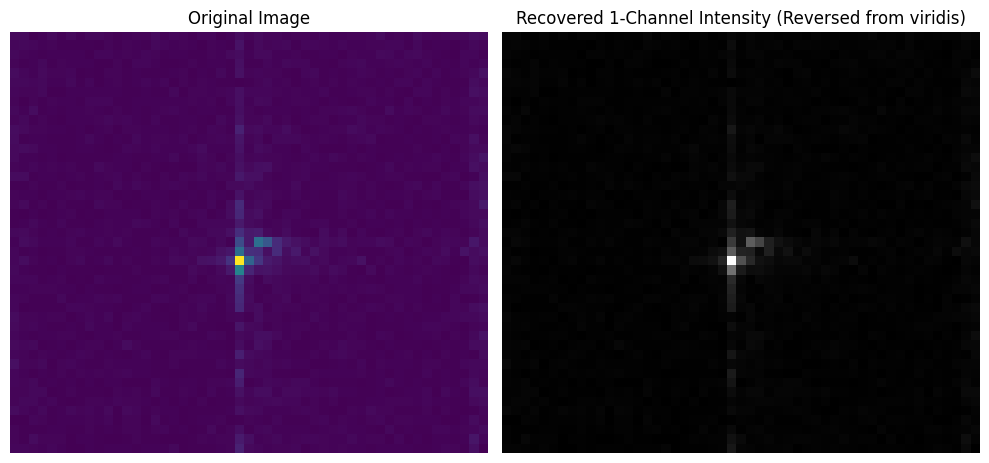

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial import cKDTree

def detect_and_reverse_colormap(img_path):
    # Load image and ensure it's RGB (drop Alpha channel if present)
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)
    
    # Common colormaps used in signal processing/radar
    colormaps_to_test = ['viridis', 'jet', 'parula', 'plasma', 'inferno']
    
    # Note: 'parula' isn't native to matplotlib, but we will test the standard ones
    available_cmaps = [cm for cm in colormaps_to_test if cm in plt.colormaps()]
    
    best_cmap = None
    lowest_error = float('inf')
    best_1ch_image = None
    
    flat_img = img_array.reshape(-1, 3)
    
    print(f"Original image shape: {img_array.shape}")
    print("Testing colormaps...")

    for cmap_name in available_cmaps:
        cmap = plt.get_cmap(cmap_name)
        
        # Create a Lookup Table (LUT) of 256 colors for this colormap
        # cmap returns RGBA (0-1), we slice [:3] for RGB and scale to 0-255
        lut = (cmap(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.float32)
        
        # Build a KDTree for fast Nearest-Neighbor color matching
        tree = cKDTree(lut)
        
        # Find the closest matching intensity value (0-255) for each pixel
        distances, indices = tree.query(flat_img)
        
        avg_error = np.mean(distances)
        print(f" - {cmap_name}: Average color distance error = {avg_error:.2f}")
        
        if avg_error < lowest_error:
            lowest_error = avg_error
            best_cmap = cmap_name
            # The indices (0-255) represent the recovered 1-channel intensity!
            best_1ch_image = indices.reshape(img_array.shape[:2]).astype(np.uint8)

    print(f"\n✅ Best matching colormap detected: '{best_cmap}'")
    print(f"New 1-channel image shape: {best_1ch_image.shape}")
    
    # Optional: expand dims if your neural network explicitly expects (51, 45, 1) instead of (51, 45)
    best_1ch_image_expanded = np.expand_dims(best_1ch_image, axis=-1)
    print(f"Shape ready for model input: {best_1ch_image_expanded.shape}")
    
    return best_1ch_image_expanded, best_cmap

if __name__ == "__main__":
    # Replace with an actual path from your x_train folder
    img_path = 'x_train/img_10.png' 
    
    try:
        intensity_image, detected_cmap = detect_and_reverse_colormap(img_path)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        # To verify visually, you can plot it
        axes[1].imshow(intensity_image.squeeze(), cmap='gray')
        axes[1].set_title(f"Recovered 1-Channel Intensity (Reversed from {detected_cmap})")
        axes[1].set_xlabel("X Pixel")
        axes[1].set_ylabel("Y Pixel")
        axes[1].axis('off')
        
        
        # Plot the original image for comparison
        original_img = Image.open(img_path).convert('RGB')
        axes[0].imshow(original_img)
        axes[0].set_title("Original Image")
        axes[0].set_xlabel("X Pixel")
        axes[0].set_ylabel("Y Pixel")
        axes[0].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"Error: Make sure {img_path} exists.")

## Conversion of Train data RGB to intensity

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os

denoising_threshold = 30  # Adjust this threshold based on your observations

def batch_preprocess_and_save(csv_path, img_dir, output_file):
    # Load labels
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}")
        return
    
    # Prepare viridis Lookup Table and KDTree
    cmap = plt.get_cmap('viridis')
    lut = (cmap(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.float32)
    tree = cKDTree(lut)
    
    num_images = len(df)
    # Pre-allocate arrays for speed. Shape: (Number of images, Height, Width, Channels)
    # Using uint8 to save memory since values are 0-255
    x_data = np.zeros((num_images, 51, 45, 1), dtype=np.uint8)
    y_data = np.zeros(num_images, dtype=np.int32)
    
    print(f"Starting conversion for {num_images} images...")
    
    # Remember: Input images are numbered from 1 and labels from 0 [cite: 26]
    for i, row in df.iterrows():
        img_id = row['id']
        label = row['target']
        img_path = os.path.join(img_dir, f"img_{img_id + 1}.png")
        
        if (i + 1) % 1000 == 0:
            print(f"Processing image {i + 1}/{num_images}...")
            
        try:
            # Load and convert to RGB
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img).reshape(-1, 3)
            
            # Find closest viridis index (0-255) for each pixel
            _, indices = tree.query(img_array)
            
            # Reshape back to image dimensions and add the channel dimension
            intensity_img = indices.reshape((51, 45, 1))

            # Denoising - clip values < denoising treshold to 0
            intensity_img[intensity_img < denoising_threshold] = 0
            
            # Store in our pre-allocated arrays
            x_data[i] = intensity_img
            y_data[i] = label
            
        except FileNotFoundError:
            print(f"Warning: {img_path} not found!")
            
    # Save the processed data into a compressed NumPy file
    np.savez_compressed(output_file, x=x_data, y=y_data)
    print(f"\n✅ Finished! Data saved to {output_file}")
    print(f"Final X shape: {x_data.shape}")
    print(f"Final Y shape: {y_data.shape}")

if __name__ == "__main__":
    # Adjust paths if your folders are named differently
    csv_file = 'y_train_v2.csv'
    image_folder = 'x_train/'
    output_filename = 'processed_train_data.npz'
    
    batch_preprocess_and_save(csv_file, image_folder, output_filename)

Starting conversion for 9227 images...
Processing image 1000/9227...
Processing image 2000/9227...
Processing image 3000/9227...
Processing image 4000/9227...
Processing image 5000/9227...
Processing image 6000/9227...
Processing image 7000/9227...
Processing image 8000/9227...
Processing image 9000/9227...

✅ Finished! Data saved to processed_train_data.npz
Final X shape: (9227, 51, 45, 1)
Final Y shape: (9227,)


In [25]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os
import re

denoising_threshold = 30  # Adjust this threshold based on your observations

def batch_preprocess_test_data(test_dir, output_file):
    # Prepare viridis Lookup Table and KDTree (same as training)
    cmap = plt.get_cmap('viridis')
    lut = (cmap(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.float32)
    tree = cKDTree(lut)
    
    # Get all PNG files in the test directory
    try:
        all_files = [f for f in os.listdir(test_dir) if f.endswith('.png')]
    except FileNotFoundError:
        print(f"Error: Could not find directory {test_dir}")
        return
    
    num_images = len(all_files)
    if num_images == 0:
        print(f"No .png files found in {test_dir}.")
        return
        
    print(f"Found {num_images} images in {test_dir}. Starting conversion...")
    
    # Pre-allocate arrays
    x_test = np.zeros((num_images, 51, 45, 1), dtype=np.uint8)
    test_ids = [] # We need to store IDs as strings/integers for the Kaggle submission
    
    # Optional: Sort files naturally so 2.png comes before 10.png
    # This handles both "1.png" and "img_1.png" formats safely
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]
    all_files.sort(key=natural_sort_key)
    
    for i, filename in enumerate(all_files):
        # 1. Remove the '.png' extension
        raw_id = os.path.splitext(filename)[0]
        
        # 2. Remove the 'img_' prefix if it is there
        clean_id = raw_id.replace('img_', '')
        
        # 3. Save the clean ID
        test_ids.append(clean_id)
        
        img_path = os.path.join(test_dir, filename)
        
        if (i + 1) % 1000 == 0:
            print(f"Processing test image {i + 1}/{num_images}...")
            
        # Load and convert to RGB
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img).reshape(-1, 3)
        
        # Find closest viridis index
        _, indices = tree.query(img_array)
        
        # Reshape and store
        intensity_img = indices.reshape((51, 45, 1))
        # Denoising - clip values < denoising treshold to 0
        intensity_img[intensity_img < denoising_threshold] = 0
        x_test[i] = intensity_img
            
    # Convert IDs to numpy array
    test_ids = np.array(test_ids)
            
    # Save the processed data into a compressed NumPy file
    # We save 'x' for the images and 'ids' for the filenames
    np.savez_compressed(output_file, x=x_test, ids=test_ids)
    print(f"\n✅ Finished! Data saved to {output_file}")
    print(f"Final x_test shape: {x_test.shape}")
    print(f"Final test_ids shape: {test_ids.shape}")

if __name__ == "__main__":
    # Ensure this points to your unzipped test folder
    test_folder = 'x_test/' 
    output_filename = 'processed_test_data.npz'
    
    batch_preprocess_test_data(test_folder, output_filename)

Found 3955 images in x_test/. Starting conversion...
Processing test image 1000/3955...
Processing test image 2000/3955...
Processing test image 3000/3955...

✅ Finished! Data saved to processed_test_data.npz
Final x_test shape: (3955, 51, 45, 1)
Final test_ids shape: (3955,)


## Example of loading preprocessed data

Loaded training data shape: (9227, 51, 45, 1)
Example x_train[5] (shape (51, 45, 1)):
[[0.         0.         0.12941177 0.15686275 0.         0.
  0.12156863 0.         0.         0.         0.13725491 0.
  0.         0.1254902  0.         0.         0.         0.
  0.         0.         0.1254902  0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.12156863 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.14509805 0.         0.        ]
 [0.         0.         0.         0.         0.11764706 0.13725491
  0.         0.15686275 0.         0.         0.         0.
  0.11764706 0.         0.         0.         0.19215687 0.12156863
  0.         0.         0.13725491 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.16470589 0.13333334 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.1372549

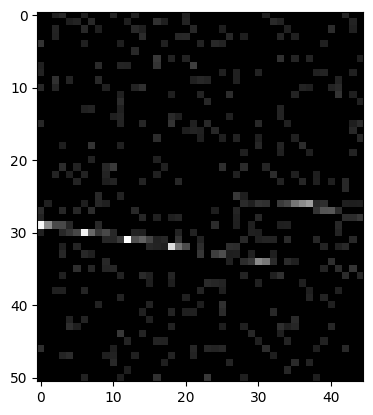

In [26]:
import numpy as np

# Load the preprocessed data
data = np.load('processed_train_data.npz')
x_train = data['x'] # 8-bit integers (0-255) representing intensity values
y_train = data['y'] # Corresponding labels (0, 1, 2, 3)

# Normalize pixel values to be between 0 and 1 for the neural network
x_train = x_train.astype('float32') / 255.0

print(f"Loaded training data shape: {x_train.shape}")

# print one example to verify
print(f"Example x_train[5] (shape {x_train[5].shape}):")
with np.printoptions(threshold=np.inf):  # Print the entire array without truncation
    print(str(x_train[5].squeeze()))  # Remove channel dimension for display

# Print the array as an image for better visualization
plt.imshow(x_train[5].squeeze(), cmap='gray')

# print y_train example
print(f"Example y_train[5]: {y_train[5]}")

# Now you can pass x_train and y_train directly to your model
# model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

✅ Successfully loaded NPZ from Google Drive!
Processed Array Shape: (9227, 51, 45, 1)
Processed Data Type: uint8
Processed Value Range: 0 to 255
----------------------------------------
✅ Successfully loaded original PNG!
Original Array Shape: (45, 51, 3)
Original Data Type: uint8
Original Value Range: 1 to 253


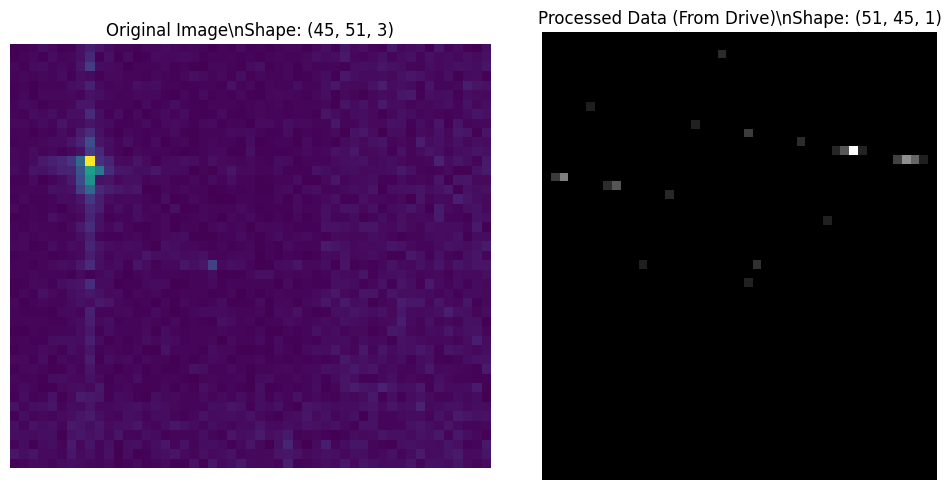

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# --- 1. Load the Preprocessed Data from Google Drive ---
drive_path = 'processed_train_data.npz'

try:
    data = np.load(drive_path)
    x_train_processed = data['x']
    print("✅ Successfully loaded NPZ from Google Drive!")
    print(f"Processed Array Shape: {x_train_processed.shape}")
    print(f"Processed Data Type: {x_train_processed.dtype}")
    print(f"Processed Value Range: {x_train_processed.min()} to {x_train_processed.max()}")
except Exception as e:
    print(f"❌ Could not load NPZ from Drive. Error: {e}")

print("-" * 40)

tested_index = 100

# --- 2. Load a "Normal" Original Image ---
# (Make sure you have the unzipped x_train folder available in your Colab runtime)
original_img_path = f'x_train/img_{tested_index}.png'

try:
    original_img = Image.open(original_img_path).convert('RGB')
    original_array = np.array(original_img)
    print("✅ Successfully loaded original PNG!")
    print(f"Original Array Shape: {original_array.shape}")
    print(f"Original Data Type: {original_array.dtype}")
    print(f"Original Value Range: {original_array.min()} to {original_array.max()}")
    
    # --- 3. Visual Comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Plot Original
    axes[0].imshow(original_array)
    axes[0].set_title(f"Original Image\\nShape: {original_array.shape}")
    axes[0].axis('off')
    
    # Plot Processed (We take index 9, squeeze out the channel dimension for plotting)
    # We use cmap='gray' to show it as raw intensity
    axes[1].imshow(x_train_processed[99].squeeze(), cmap='gray')
    axes[1].set_title(f"Processed Data (From Drive)\\nShape: {x_train_processed[99].shape}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Could not load original PNG. Make sure 'x_train' is uploaded. Error: {e}")

Comparing arrays from local and drive...
❌ The arrays differ! There may be an issue with the upload/download process.


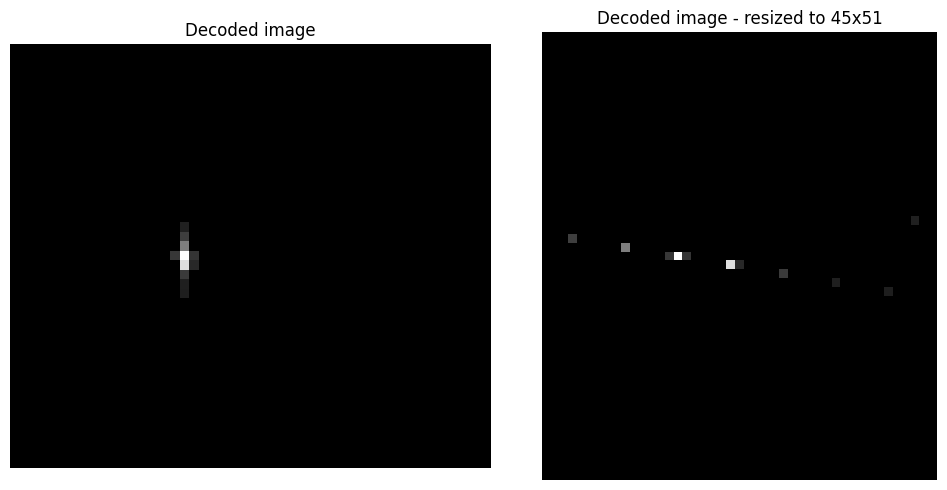

Second lowest non-zero value in the array: 30


In [22]:
path = 'processed_train_data.npz'

data = np.load(path)
x_train_processed = data['x']

drive_path = 'processed_train_data_corr.npz'

data_drive = np.load(drive_path)
x_train_drive = data_drive['x']

# compare content of both arrays
print("Comparing arrays from local and drive...")   
if np.array_equal(x_train_processed, x_train_drive):
    print("✅ The arrays are identical!")
else:
    print("❌ The arrays differ! There may be an issue with the upload/download process.")
    index_of_printed_image = 1
    # print both first images for visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 
    axes[0].imshow(x_train_drive[index_of_printed_image].squeeze(), cmap='gray')
    axes[0].set_title("Decoded image")
    axes[0].axis('off')
    axes[1].imshow(x_train_processed[index_of_printed_image].squeeze(), cmap='gray')
    axes[1].set_title("Decoded image - resized to 45x51")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    
# Print second lowest value different than zero in the array to check if denoising worked
non_zero_values = x_train_drive[x_train_drive > 0]
if len(non_zero_values) > 1:
    second_lowest = np.partition(non_zero_values.flatten(), 1)[1]
    print(f"Second lowest non-zero value in the array: {second_lowest}")

    

In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os

denoising_threshold = 0  # Adjust this threshold based on your observations

def batch_preprocess_and_save(csv_path, img_dir, output_file):
    # Load labels
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}")
        return
    
    # Prepare viridis Lookup Table and KDTree
    cmap = plt.get_cmap('viridis')
    lut = (cmap(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.float32)
    tree = cKDTree(lut)
    
    num_images = len(df)
    # Pre-allocate arrays for speed. Shape: (Number of images, Height, Width, Channels)
    # Using uint8 to save memory since values are 0-255
    x_data = np.zeros((num_images, 45, 51, 1), dtype=np.uint8)
    y_data = np.zeros(num_images, dtype=np.int32)
    
    print(f"Starting conversion for {num_images} images...")
    
    # Remember: Input images are numbered from 1 and labels from 0 [cite: 26]
    for i, row in df.iterrows():
        img_id = row['id']
        label = row['target']
        img_path = os.path.join(img_dir, f"img_{img_id + 1}.png")
        
        if (i + 1) % 1000 == 0:
            print(f"Processing image {i + 1}/{num_images}...")
            
        try:
            # Load and convert to RGB
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img).reshape(-1, 3)
            
            # Find closest viridis index (0-255) for each pixel
            _, indices = tree.query(img_array)
            intensity_img = indices.reshape((45, 51, 1))

            

            # Denoising - clip values < denoising treshold to 0
            intensity_img[intensity_img < denoising_threshold] = 0
            
            # Store in our pre-allocated arrays
            x_data[i] = intensity_img
            y_data[i] = label
            
        except FileNotFoundError:
            print(f"Warning: {img_path} not found!")
            
            
    # Save the processed data into a compressed NumPy file
    np.savez_compressed(output_file, x=x_data, y=y_data)
    print(f"\n✅ Finished! Data saved to {output_file}")
    print(f"Final X shape: {x_data.shape}")
    print(f"Final Y shape: {y_data.shape}")

if __name__ == "__main__":
    # Adjust paths if your folders are named differently
    csv_file = 'y_train_v2.csv'
    image_folder = 'x_train/'
    output_filename = 'processed_train_data_corr_threshold0.npz'
    
    batch_preprocess_and_save(csv_file, image_folder, output_filename)

Starting conversion for 9227 images...
Processing image 1000/9227...
Processing image 2000/9227...
Processing image 3000/9227...
Processing image 4000/9227...
Processing image 5000/9227...
Processing image 6000/9227...
Processing image 7000/9227...
Processing image 8000/9227...
Processing image 9000/9227...

✅ Finished! Data saved to processed_train_data_corr_threshold0.npz
Final X shape: (9227, 45, 51, 1)
Final Y shape: (9227,)


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os
import re

denoising_threshold = 0  # Adjust this threshold based on your observations

def batch_preprocess_test_data(test_dir, output_file):
    # Prepare viridis Lookup Table and KDTree (same as training)
    cmap = plt.get_cmap('viridis')
    lut = (cmap(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.float32)
    tree = cKDTree(lut)
    
    # Get all PNG files in the test directory
    try:
        all_files = [f for f in os.listdir(test_dir) if f.endswith('.png')]
    except FileNotFoundError:
        print(f"Error: Could not find directory {test_dir}")
        return
    
    num_images = len(all_files)
    if num_images == 0:
        print(f"No .png files found in {test_dir}.")
        return
        
    print(f"Found {num_images} images in {test_dir}. Starting conversion...")
    
    # Pre-allocate arrays
    x_test = np.zeros((num_images, 45, 51, 1), dtype=np.uint8)
    test_ids = [] # We need to store IDs as strings/integers for the Kaggle submission
    
    # Optional: Sort files naturally so 2.png comes before 10.png
    # This handles both "1.png" and "img_1.png" formats safely
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]
    all_files.sort(key=natural_sort_key)
    
    for i, filename in enumerate(all_files):
        # 1. Remove the '.png' extension
        raw_id = os.path.splitext(filename)[0]
        
        # 2. Remove the 'img_' prefix if it is there
        clean_id = raw_id.replace('img_', '')
        
        # 3. Save the clean ID
        test_ids.append(clean_id)
        
        img_path = os.path.join(test_dir, filename)
        
        if (i + 1) % 1000 == 0:
            print(f"Processing test image {i + 1}/{num_images}...")
            
        # Load and convert to RGB
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img).reshape(-1, 3)
        
        # Find closest viridis index
        _, indices = tree.query(img_array)
        
        # Reshape and store
        intensity_img = indices.reshape((45, 51, 1))
        # Denoising - clip values < denoising treshold to 0
        intensity_img[intensity_img < denoising_threshold] = 0
        x_test[i] = intensity_img
            
    # Convert IDs to numpy array
    test_ids = np.array(test_ids)
            
    # Save the processed data into a compressed NumPy file
    # We save 'x' for the images and 'ids' for the filenames
    np.savez_compressed(output_file, x=x_test, ids=test_ids)
    print(f"\n✅ Finished! Data saved to {output_file}")
    print(f"Final x_test shape: {x_test.shape}")
    print(f"Final test_ids shape: {test_ids.shape}")

if __name__ == "__main__":
    # Ensure this points to your unzipped test folder
    test_folder = 'x_test/' 
    output_filename = 'processed_test_data_corr_threshold0.npz'
    
    batch_preprocess_test_data(test_folder, output_filename)

Found 3955 images in x_test/. Starting conversion...
Processing test image 1000/3955...
Processing test image 2000/3955...
Processing test image 3000/3955...

✅ Finished! Data saved to processed_test_data_corr.npz
Final x_test shape: (3955, 45, 51, 1)
Final test_ids shape: (3955,)
